### Delay 보정을 해서 AEC

In [1]:
import numpy as np
import scipy

def estimate_delay (s1, s2):
    corr = scipy.signal.correlate(s1, s2, mode='full')
    
    # 최대 correlation 값의 index를 찾아서 delay 계산
    delay = np.argmax(corr) - len(s2) + 1
    return delay

In [2]:
import numpy as np
from scipy.fft import rfft, irfft, fftshift

def estimate_delay_gcc_phat_corrected(s1, s2):
    s1 = np.asarray(s1)
    s2 = np.asarray(s2)

    n = s1.shape[0] + s2.shape[0] - 1

    S1 = rfft(s1, n=n)
    S2 = rfft(s2, n=n)

    R = S1 * np.conj(S2)
    R_phat = R / (np.abs(R) + 1e-10)

    gcc = irfft(R_phat, n=n)
    
    # --- 이 부분이 수정되었습니다 ---
    # fftshift를 사용하여 zero-lag이 배열 중앙에 오도록 재정렬
    gcc_shifted = fftshift(gcc)
    
    # 재정렬된 배열에서 최대값의 index를 찾음
    peak_index = np.argmax(np.abs(gcc_shifted))
    
    # 중앙 index를 빼서 실제 delay 값을 계산
    delay = peak_index - (len(gcc_shifted) // 2)

    return delay

In [3]:
def align_signals(mic_signal, ref_signal, delay):
    mic_signal = np.asarray(mic_signal)
    ref_signal = np.asarray(ref_signal)
    
    if delay > 0:
        print(f"Mic 신호가 {delay} 샘플만큼 늦습니다. 정렬을 수행합니다.")
        ref_aligned = ref_signal[:-delay]
        mic_aligned = mic_signal[delay:]
        
    elif delay < 0:
        abs_delay = abs(delay)
        print(f"Mic 신호가 {abs_delay} 샘플만큼 빠릅니다. 정렬을 수행합니다.")
        ref_aligned = ref_signal[abs_delay:]
        mic_aligned = mic_signal[:-abs_delay]
        
    else:
        print("지연 시간이 없어 정렬이 필요 없습니다.")
        ref_aligned = ref_signal
        mic_aligned = mic_signal
        
    return mic_aligned, ref_aligned

In [4]:
import numpy as np
import soundfile as sf
import os

import matplotlib.pyplot as plt
import AEC_speex as aec
input_filename = "../data/Echoonly_60dB.wav"

temp, sr = sf.read(input_filename)
mic = temp[:, 0]
ref = temp[:, 2]

# mic = mic/np.max(mic)
# ref = ref/np.max(ref)

delay = estimate_delay_gcc_phat_corrected(mic, ref)
print(delay)

-18


In [ ]:
mic, ref = align_signals(mic, ref, delay)

aec_speech, aec_echo = aec.run_AEC(ref, mic, sr, processor=aec.MDF,
                                   output_filename="Echoonly"
                                   )
erle = aec.calculate_erle(mic, aec_echo, opt_print=True)
erle

Mic 신호가 18 샘플만큼 빠릅니다. 정렬을 수행합니다.
CALCULATING ERLE FOR 'real' DATA ... 

3.2601730401525346

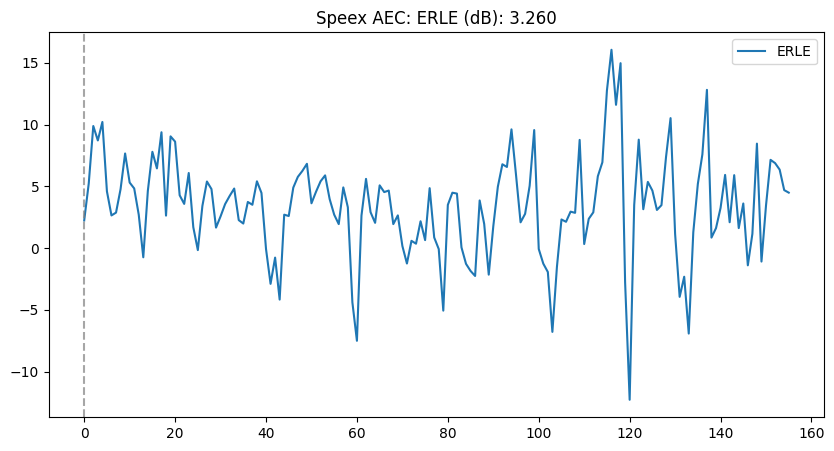

In [6]:
# ERLE graph
# aec_echo, _ = sf.read("../data/Output/Kalman_Echoonly_echo.wav")
# erle = aec.calculate_erle(mic, aec_echo[:len(mic)], opt_print=True)
# erle

win_erle_1 = aec.windowed_calculate_erle(mic, aec_echo[:len(mic)])

plt.figure(figsize=(10, 5))
plt.plot(win_erle_1, label="ERLE")
plt.legend()

spacing = int(len(mic)/1024)  # 간격
for xc in range(0, len(win_erle_1), spacing):
    plt.axvline(x=xc, color='gray', linestyle='--', alpha=0.7)
    
plt.title(f"Speex AEC: ERLE (dB): {erle:.3f}")
plt.show()